<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lesson_6_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 6.1 (TBD) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1. [Learning Outcomes](#Learning-Outcomes)

2. [Introduction](#Introduction)

3. [Pendulums](#Pendulums)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

#<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b>

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

#<font size = 6> <b> 2. Introduction </b> </font>

---

##<font size = 5> <b> 2.1 Introduction to Harmonic Oscillators </b> </font>

---

##<font size = 5> <b> 2.2 Prepare the Program </b> </font>

### <b> Import Libraries </b>

In [1]:
##=============================================================================================##
## Import Libraries:                                                                           ##
##=============================================================================================##

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.optimize as spo
import matplotlib.pyplot as plt

from IPython.display import display_html

### <b> Define Display and Plot Functions </b>

In [2]:
#@title This cell defines the functions: display_dataframes and plot_data

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  dataframe_list - List of DataFrames to be displayed                              ##
##            title_list     - List of titles for the displayed DataFrames                     ##
##            n_items        - Number of items to display (optional, default = 5)              ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(dataframe_list, title_list, n_items = 5, tail = False):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ""

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(dataframe_list, title_list):

    # Convert the current dataframe info to html:

    if (tail == True):

      html_df = pd.DataFrame(df).tail(n_items).to_html()

    else:

      html_df = pd.DataFrame(df).head(n_items).to_html()

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

    html_str += "<div style='display: inline-block; margin-right: 20px; vertical-align: top;'>"

    html_str += "<h3 style='text-align: center;'>" + str(title) + "</h3><hr>" + str(html_df)

    html_str += "</div>"

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Create a Function to Make Plots:                                                            ##
##=============================================================================================##

def plot_data(data_list, x_list = [], y_list = [], color_list = [], title_list = [],
              x_label_list = [], y_label_list = [], aspect_list = [], legend_list = [],
              overplot = False):

  ##===========================================================================================##
  ## If overplot is True, create an overplot of the graphs:                                    ##
  ##===========================================================================================##

  if (overplot == True):

    # Create the graph:

    x = x_list[0]
    y = y_list[0]

    x_size = 10
    y_size = 10 * aspect_list[0]

    ax = plt.figure(figsize = (x_size, y_size)).add_subplot(111)

    # Set the graph title:

    ax.set_title(title_list[0], fontsize = 14)

    # Set the Graph x-axis label:

    ax.set_xlabel(x_label_list[0], fontsize = 12)

    # Set the Graph y-axis label:

    ax.set_ylabel(y_label_list[0], fontsize = 12)

    # Add grid and the legend:

    ax.grid(True, linestyle = '--', alpha = 0.5)

    # Overplot the remaining data:

    for data, color, label in zip(data_list, color_list, legend_list):

      ax.plot(data[x], data[y], color = color, label = label)

    # Display the plots:

    plt.legend()

    plt.show()

  ##===========================================================================================##
  ## If overplot is False, create a series of graphs:                                          ##
  ##===========================================================================================##

  else:

    # Get the settings for each graph to be made:

    for X, Y, color, title, x_label, y_label, aspect in \
      zip(x_list, y_list, color_list, title_list, x_label_list, y_label_list, aspect_list):

      # Create the graph:

      x_size = 10
      y_size = 10 * aspect

      ax = data_list[0].plot(
        kind    = 'line',
        y       = [Y],
        x       = str(X),
        color   = [color],
        figsize = (x_size, y_size)
      )

      # Set the graph title:

      ax.set_title(title, fontsize = 14)

      # Set the Graph x-axis label:

      ax.set_xlabel(x_label, fontsize = 12)

      # Set the Graph y-axis label:

      ax.set_ylabel(y_label, fontsize = 12)

      # Add grid and suppress the legend:

      ax.grid(True, linestyle = '--', alpha = 0.5)

      legend = ax.legend(title = "Model")

      legend.remove()

    # Display the plots:

    plt.show()

### <b> Define Differential Equation Solver Algorithms </b>

In [3]:
#@title This cell defines the Euler, Euler-Cromer, Euler-Richardson, and Runge-Kutta 4th Order DEQ Solver Algorithms.

##=============================================================================================##
## Define the 1D Euler Algorithm Change Function:                                              ##
##=============================================================================================##

def cf_euler_1d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['Position']

  # Get the current velocity:

  v = state_local['Velocity']

  # Get the current acceleration:

  a = acceleration(state_local, parameters)

  # Update the position:

  x += v * dt

  # Update the velocity:

  v += a * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['Position'] = x

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

##=============================================================================================##
## Define the 1D Euler-Cromer Algorithm Function:                                              ##
##=============================================================================================##

def cf_euler_cromer_1d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['Position']

  # Get the current velocity:

  v = state_local['Velocity']

  # Get the current acceleration:

  a = acceleration(state_local, parameters)

  # Update the velocity:

  v += a * dt

  # Update the position:

  x += v * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['Position'] = x

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

##=============================================================================================##
## Define the 1D Euler Algorithm Function:                                                     ##
##=============================================================================================##

def cf_euler_richardson_1d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['Position']

  # Get the current velocity:

  v = state_local['Velocity']

  # Get the current acceleration:

  a = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Get the Midpoint Values:                                                                  ##
  ##===========================================================================================##

  # Calculate the midpoint velocity:

  v_mid = v + a * dt / 2

  # Calculate the midpoint position:

  x_mid = x + v * dt / 2

  # Update the local state:

  state_local['Position'] = x_mid

  state_local['Velocity'] = v_mid

  # Calculate the midpoint acceleration:

  a_mid = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the Updated Values:                                                             ##
  ##===========================================================================================##

  # Update the position:

  x += v_mid * dt

  # Update the velocity:

  v += a_mid * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['Position'] = x

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

##=============================================================================================##
## Define the 1D Runge-Kutta Change Function:                                                  ##
##=============================================================================================##

def cf_runge_kutta_1d(state, parameters, acceleration):

  # Create a local copy of the state object:

  state_local = state.copy()

  # Unpack the state:

  y = state_local['Position']

  v = state_local['Velocity']

  # Unpack the parameters:

  dt = parameters['dt']

  # Compute the acceleration:

  a = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the k1 Values (Slope at the Beginning of the Time Step):                        ##
  ##===========================================================================================##

  k1_y = v

  k1_v = a

  ##===========================================================================================##
  ## Calculate the k2 Values (Slope at the Midpoint of the Time Step, Based on k1 Values):     ##
  ##===========================================================================================##

  # Position k2 values:

  k2_y = v + 0.5 * k1_v * dt

  # Velocity k2 values:

  y_mid_1 = y + 0.5 * k1_y * dt

  v_mid_1 = v + 0.5 * k1_v * dt

  # Acceleration k2 values:

  state_local['Position'] = y_mid_1

  state_local['Velocity'] = v_mid_1

  k2_v = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the k3 Values (Slope at the Midpoint of the Time Step, Based on k2 Values):     ##
  ##===========================================================================================##

  # Position k3 values:

  k3_y = v + 0.5 * k2_v * dt

  # Velocity k3 values:

  y_mid_2 = y + 0.5 * k2_y * dt

  v_mid_2 = v + 0.5 * k2_v * dt

  # Acceleration k3 values:

  state_local['Position'] = y_mid_2

  state_local['Velocity'] = v_mid_2

  k3_v = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the k4 Values (Slope at the End of the Time Step, Based on k3 Values):          ##
  ##===========================================================================================##

  # Position k4 values:

  k4_y = v + k3_v * dt

  # Velocity k4 values:

  y_end = y + k3_y * dt

  v_end = v + k3_v * dt

  # Acceleration k4 values:

  state_local['Position'] = y_end

  state_local['Velocity'] = v_end

  k4_v = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Update the State Values:                                                                  ##
  ##===========================================================================================##

  # Update the object's velocity:

  v += (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v) * dt / 6.0

  # Update the object's position:

  y += (k1_y + 2.0 * k2_y + 2.0 * k3_y + k4_y) * dt / 6.0

  # Update the local state positions:

  state_local['Position'] = y

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  # Return the updated local state:

  return state_local

### <b> Define the Run Simulation and Analyze Simulation Functions </b>

In [4]:
#@title This cell defines the run_simulation and analyze_simulation functions.

##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters, initial_state, change_function, acceleration, show_wtime = False):

  ##===========================================================================================##
  ## Get the Simulation Start Time:                                                            ##
  ##===========================================================================================##

  wall_start_time = tm.time()

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Get the end time:

  end_time = parameters.loc['t_end']

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Motion Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  end_condition = False

  while (end_condition == False):

    # Get the current time step:

    i = state_history.index[-1]

    # Get the state of the system for the current time step:

    state = change_function(state, parameters, acceleration)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = state.T

    # If an end condition has been reached, break the loop:

    if (state['Time'] >= end_time): end_condition = True

  ##===========================================================================================##
  ## Get the Simulation End Time:                                                              ##
  ##===========================================================================================##

  wall_end_time = tm.time()

  if (show_wtime == True):

    print("Elapsed Simulation Runtime:", np.round(wall_end_time - wall_start_time, 5), "seconds")

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

##=============================================================================================##
## Create a Function to Analyze the Simulation Results:                                        ##
##=============================================================================================##

def analyze_simulation(state_history, parameters, loss_function, acceleration, x_list = [],
                       y_list = [], color_list = [], title_list = [], x_label_list = [],
                       y_label_list = [], aspect_list = [], plot = False, display = False):

  ##===========================================================================================##
  ## Compute the Simulation_Loss:                                                              ##
  ##===========================================================================================##

  loss_history = loss_function(parameters, state_history, acceleration)

  ##===========================================================================================##
  ## Add the Loss History to the State History:                                                ##
  ##===========================================================================================##

  state_history['Loss'] = loss_history

  ##===========================================================================================##
  ## If requested, display the history data:                                                   ##
  ##===========================================================================================##

  if (display == True):

    display_dataframes([state_history, state_history.iloc[-1]],["State History", "Final State"],
                       n_items = 5)

  ##===========================================================================================##
  ## If requested, plot the history data:                                                      ##
  ##===========================================================================================##

  if (plot == True):

    plot_data([state_history], x_list, y_list, color_list, title_list, x_label_list,
              y_label_list, aspect_list, legend_list = [])

---

##<font size = 5> <b> 2.3 Set the SHO Simulation Parameters and Initial State </b> </font>

### <b> Define the Simple Harmonic Oscillator Simulation Parameters </b>

In [5]:
##=============================================================================================##
## Simple Harmonic Oscillator Parameters:                                                      ##
##=============================================================================================##

# Equilibrium position (meters):

x_eq = 0.0

# SHO Force Coefficient (N / m):

k = np.pi**2

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 10

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_sho = pd.Series({
    "x_eq":   x_eq,
    "k":      k,
    "dt":     dt,
    "t_end":  t_end
})

##=============================================================================================##
## Rename the Columns:                                                                         ##
##=============================================================================================##

parameters_sho.name = 'Value'

parameters_sho.index.name = "Parameter"

### <b> Define the Harmonic Oscillator Initial State </b>

In [6]:
##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

# Initial Position:

x_initial = 1.0 # distance units

# Initial Velocity:

v_initial = 0 # distance units per second

# Initial Time:

t_initial = 0 # seconds

##=============================================================================================##
## Store the initial state in a Pandas Series:                                                 ##
##=============================================================================================##

initial_state_ho = pd.Series({
    "Position" : x_initial,
    "Velocity" : v_initial,
    "Time"     : t_initial
})

initial_state_ho.name = 'Value'

initial_state_ho.index.name = "State"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_sho, initial_state_ho],
                   ["SHO Parameters", "HO Initial State"], n_items = 15)

,Value
Parameter,
x_eq,0.000000
k,9.869604
dt,0.010000
t_end,10.000000
,Value
State,
Position,1.0
Velocity,0.0
Time,0.0


---

##<font size = 5> <b> 2.4 Define the Simple Harmonic Oscillator Acceleration Function </b> </font>

In [7]:
##=============================================================================================##
## Define the Acceleration Function For the Simple Harmonic Oscillator Simulation:             ##
##=============================================================================================##

def acceleration_sho(state, parameters):

  ##===========================================================================================##
  ## Unpack Parameter Values:                                                                  ##
  ##===========================================================================================##

  # Get the equilibrium position:

  x_eq = parameters["x_eq"]

  # Get the sho force coefficient:

  k = parameters["k"]

  ##===========================================================================================##
  ## Unpack State Values:                                                                      ##
  ##===========================================================================================##

  # Get the object's current position:

  x = state["Position"]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the acceleration:

  acceleration = - k * (x - x_eq)

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration

---

##<font size = 5> <b> 2.5 Define the Harmonic Oscillator Loss Function </b> </font>

In [8]:
##=============================================================================================##
## Create a Function to Calculate Loss:                                                        ##
##=============================================================================================##

def loss_ho(parameters, state_history, acceleration):

  ##===========================================================================================##
  ## Unpack Parameter Values:                                                                  ##
  ##===========================================================================================##

  # Get the equilibrium position:

  x_eq = parameters["x_eq"]

  # Get the force coefficient:

  k = parameters["k"]

  # Get the time step:

  dt = parameters['dt']

  ##===========================================================================================##
  ## Unpack History Values:                                                                    ##
  ##===========================================================================================##

  # Get the position values:

  x_initial = state_history.iloc[0]['Position']

  x_history = state_history.iloc[:]['Position']

  # Get the velocity values:

  v_initial = state_history.iloc[0]['Velocity']

  v_history = state_history.iloc[:]['Velocity']

  ##===========================================================================================##
  ## Calculate the Total Energy Initial:                                                       ##
  ##===========================================================================================##

  potential_energy_initial = 0.5 * k * (x_initial - x_eq) ** 2

  kinetic_energy_initial = 0.5 * (v_initial) ** 2

  total_energy_initial = potential_energy_initial + kinetic_energy_initial

  ##===========================================================================================##
  ## Calculate the Total Energy History:                                                       ##
  ##===========================================================================================##

  potential_energy_history = 0.5 * k * (x_history - x_eq) ** 2

  kinetic_energy_history = 0.5 * (v_history) ** 2

  total_energy_history = potential_energy_history + kinetic_energy_history

  ##===========================================================================================##
  ## Calculate the Energy Lost to Non-Conservative Forces (Work / mass = acc * velocity * dt): ##
  ##===========================================================================================##

  # Compute the acceleration due to non-conservative forces:

  acc_nc = acceleration(state_history, parameters) + k * (x_history - x_eq)

  # Compute the non-conservative work / mass:

  work = (v_history * acc_nc * dt).cumsum()

  ##===========================================================================================##
  ## Calculate the Loss History:                                                               ##
  ##===========================================================================================##

  loss_history = (total_energy_history - total_energy_initial - work) / total_energy_initial

  ##===========================================================================================##
  ## Return the Loss History:                                                                  ##
  ##===========================================================================================##

  return loss_history

---

##<font size = 5> <b> 2.6 Run the Simple Harmonic Oscillator Simulation </b> </font>

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.000000 
 0.000000 
 0.00 
 0.000000e+00 
 
 
 1 
 0.999507 
 -0.098680 
 0.01 
 -1.335111e-11 
 
 
 2 
 0.998027 
 -0.197262 
 0.02 
 -2.670204e-11 
 
 
 3 
 0.995562 
 -0.295650 
 0.03 
 -4.005296e-11 
 
 
 4 
 0.992115 
 -0.393746 
 0.04 
 -5.340407e-11 
 
 
 Final State 
 
 
 
 1001 
 
 
 Time Step 
 
 
 
 
 
 Position 
 9.995066e-01 
 
 
 Velocity 
 -9.867901e-02 
 
 
 Time 
 1.001000e+01 
 
 
 Loss 
 -1.336433e-08

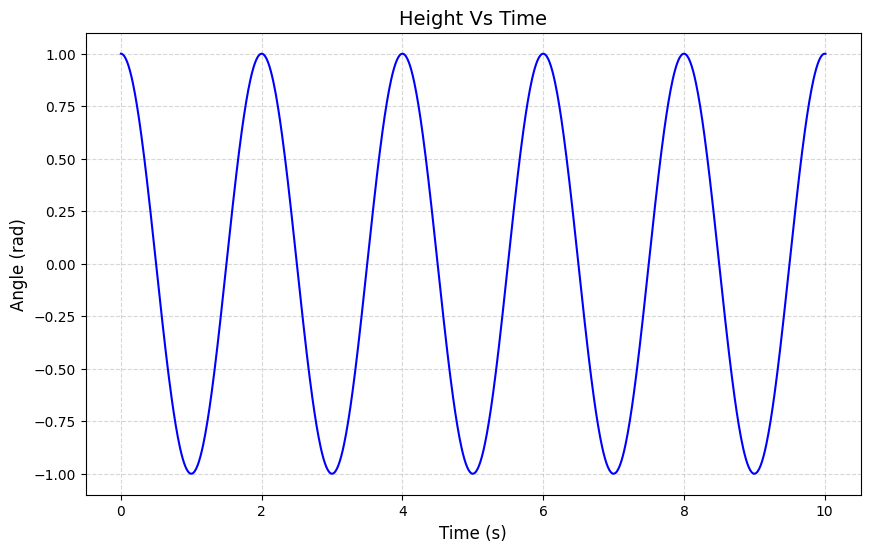

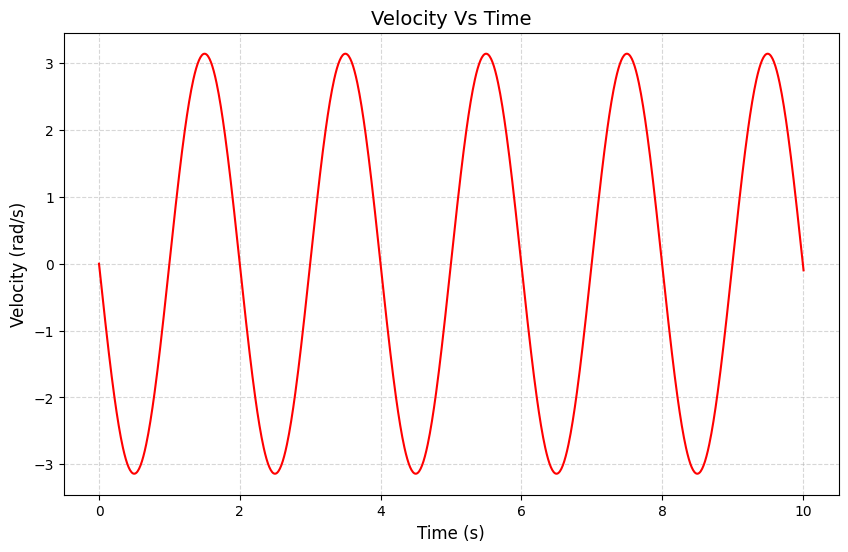

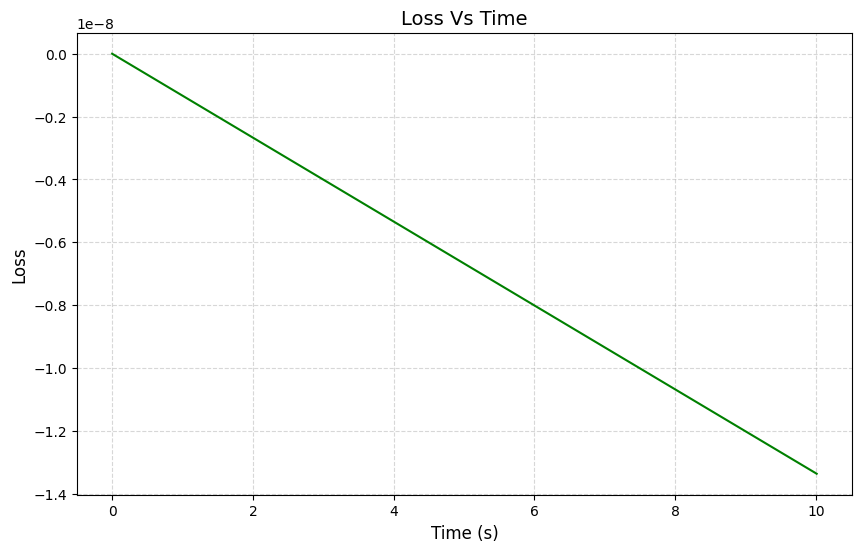

In [9]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_sho.copy()

# Set the desired initial state:

state = initial_state_ho.copy()

# Set the desired acceleration function:

acceleration = acceleration_sho

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_sho = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_sho

# Set the Loss Function:

loss = loss_ho

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

---

##<font size = 5> <b> 2.7 Set the Damped-Driven Harmonic Oscillator Simulation Parameters </b> </font>

In [10]:
##=============================================================================================##
## Damped-Driven Harmonic Oscillator Parameters:                                               ##
##=============================================================================================##

# Equilibrium position (meters):

x_eq = 0.0

# SHO Force Coefficient (N / m):

k = np.pi**2

# Damping force coefficient:

C = 1.0

# Driving force amplitude:

A = 1.0

# Driving force frequency:

f = 1.0

# Driving force phase:

phi = np.pi / 2.0

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 15

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_damped_driven = pd.Series({
    "x_eq":   x_eq,
    "k":      k,
    "C":      C,
    "A":      A,
    "f":      f,
    "phi":    phi,
    "dt":     dt,
    "t_end":  t_end
})

##=============================================================================================##
## Rename the Columns:                                                                         ##
##=============================================================================================##

parameters_damped_driven.name = 'Value'

parameters_damped_driven.index.name = "Parameter"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_damped_driven, initial_state_ho],
                   ["Damped-Driven HO Parameters", "HO Initial State"], n_items = 15)

,Value
Parameter,
x_eq,0.000000
k,9.869604
C,1.000000
A,1.000000
f,1.000000
phi,1.570796
dt,0.010000
t_end,15.000000
,Value


---

##<font size = 5> <b> 2.8 Define the Damped-Driven Harmonic Oscillator Acceleration Function </b> </font>

In [11]:
##=============================================================================================##
## Define the Acceleration Function For the Damped-Driven Harmonic Oscillator Simulation:      ##
##=============================================================================================##

def acceleration_damped_driven(state, parameters):

  ##===========================================================================================##
  ## Unpack Parameter Values:                                                                  ##
  ##===========================================================================================##

  # Get the equilibrium position:

  x_eq = parameters["x_eq"]

  # Get the sho force coefficient:

  k = parameters["k"]

  # Get the damping force coefficent:

  C = parameters["C"]

  # Get the driving force amplitude:

  A = parameters["A"]

  # Get the driving force frequency:

  f = parameters["f"]

  # Get the driving force phase:

  phi = parameters["phi"]

  ##===========================================================================================##
  ## Unpack State Values:                                                                      ##
  ##===========================================================================================##

  # Get the object's current position:

  x = state["Position"]

  # Get the object's current velocity:

  v = state["Velocity"]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the simple harmonic acceleration:

  acceleration_sho = - k * (x - x_eq)

  # Calculate the driving force acceleration:

  acceleration_driven = A * np.cos((2 * np.pi) * f * state["Time"] + phi)

  # Calculate the damping force acceleration:

  acceleration_drag = - C * v

  # Calculate the net acceleration:

  acceleration_net = acceleration_sho + acceleration_driven + acceleration_drag

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration_net

---

##<font size = 5> <b> 2.9 Run the Damped-Driven Harmonic Oscillator Simulation </b> </font>

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.000000 
 0.000000 
 0.00 
 0.000000e+00 
 
 
 1 
 0.999507 
 -0.098680 
 0.01 
 -1.335111e-11 
 
 
 2 
 0.998027 
 -0.197262 
 0.02 
 -2.670204e-11 
 
 
 3 
 0.995562 
 -0.295650 
 0.03 
 -4.005296e-11 
 
 
 4 
 0.992115 
 -0.393746 
 0.04 
 -5.340407e-11 
 
 
 Final State 
 
 
 
 1501 
 
 
 Time Step 
 
 
 
 
 
 Position 
 -9.995066e-01 
 
 
 Velocity 
 9.867861e-02 
 
 
 Time 
 1.501000e+01 
 
 
 Loss 
 -2.003982e-08

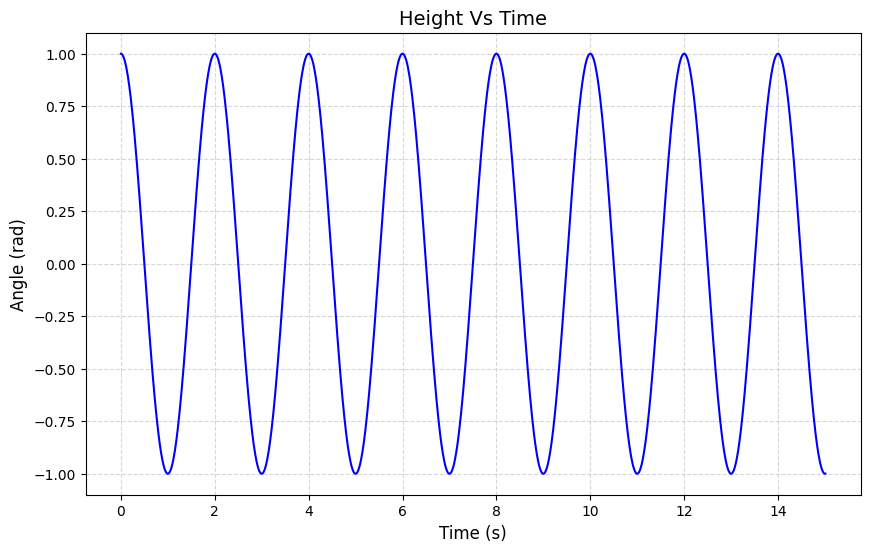

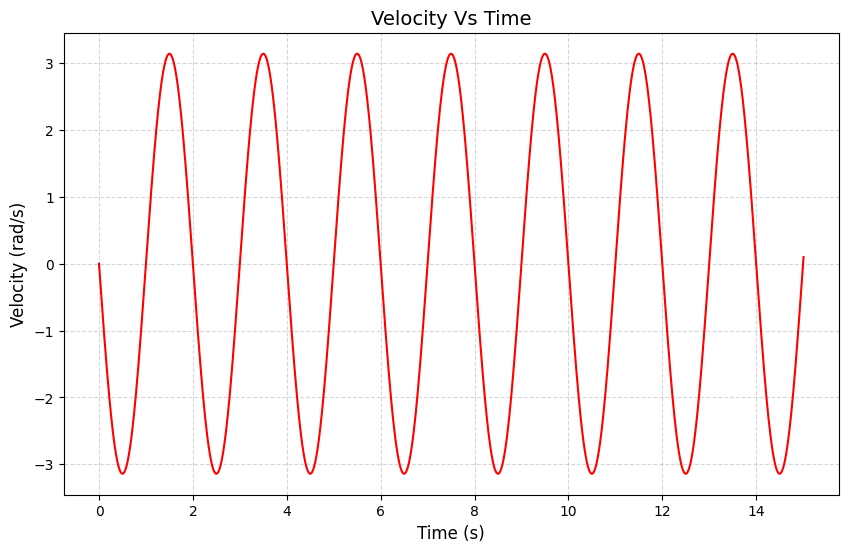

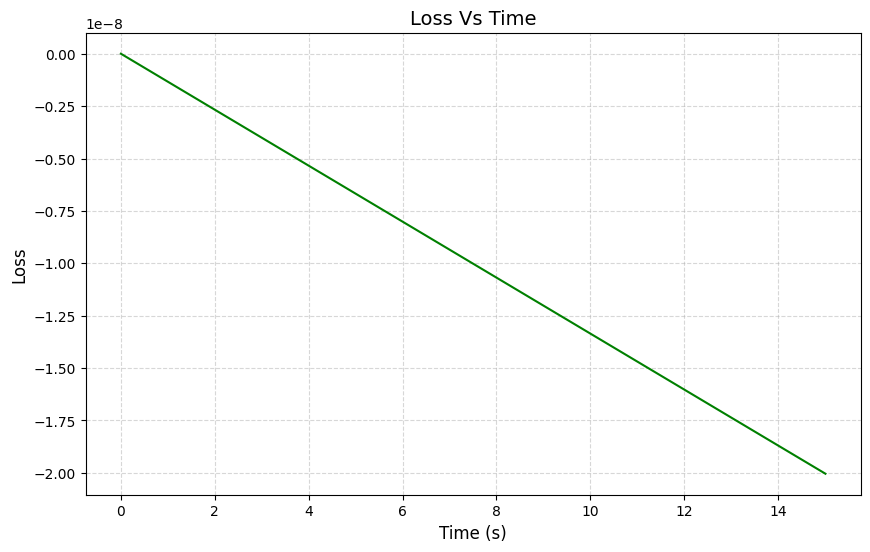

In [15]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_damped_driven.copy()

# Set the desired damping force coefficient:

parameters['C'] = 0.0

# Set the desired driving force amplitude:

parameters['A'] = 0.0

# Set the desired initial state:

state = initial_state_ho.copy()

# Set the desired acceleration function:

acceleration = acceleration_damped_driven

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_damped_driven = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_damped_driven

# Set the Loss Function:

loss = loss_ho

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

---

##<font size = 5> <b> 2.10 Resonance in Harmonic Oscillators </b> </font>

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.000000 
 0.000000 
 0.00 
 0.000000 
 
 
 1 
 0.999507 
 -0.098680 
 0.01 
 -0.000006 
 
 
 2 
 0.998025 
 -0.197576 
 0.02 
 -0.000022 
 
 
 3 
 0.995554 
 -0.296592 
 0.03 
 -0.000047 
 
 
 4 
 0.992093 
 -0.395627 
 0.04 
 -0.000082 
 
 
 Final State 
 
 
 
 1501 
 
 
 Time Step 
 
 
 
 
 
 Position 
 -3.386438 
 
 
 Velocity 
 0.216477 
 
 
 Time 
 15.010000 
 
 
 Loss 
 0.001570

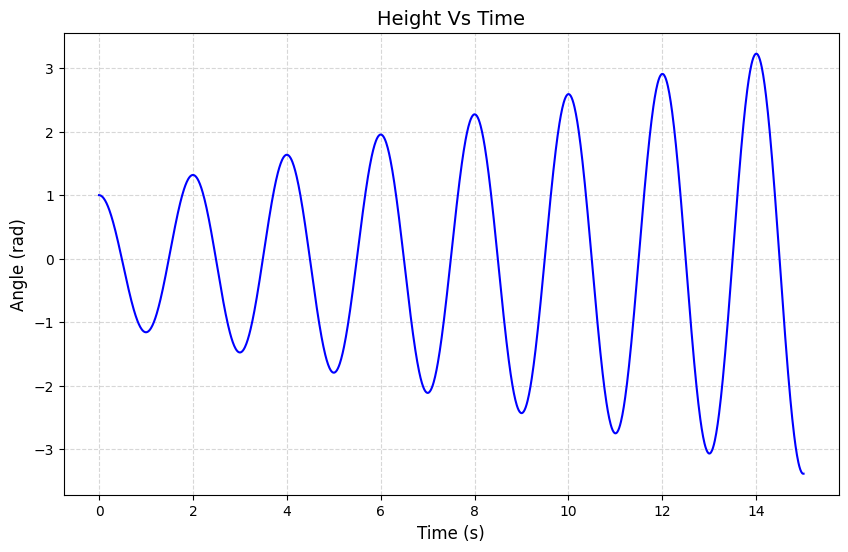

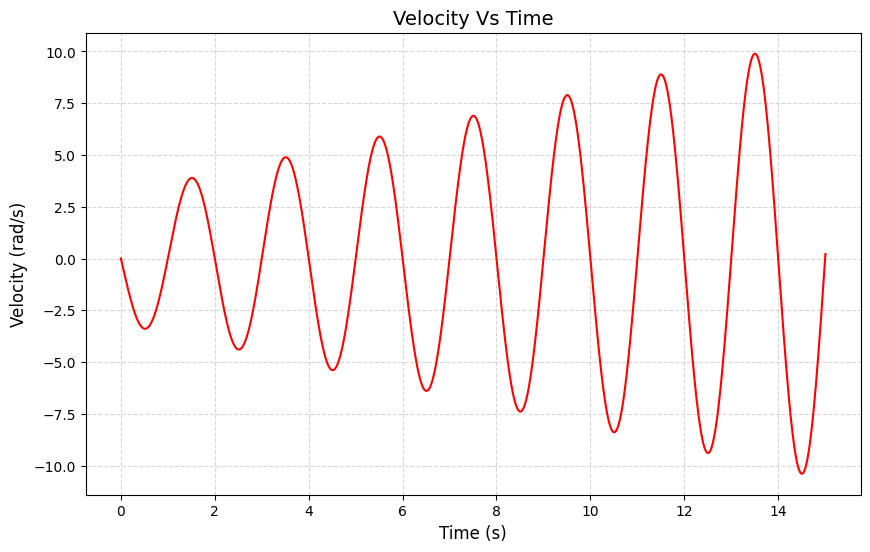

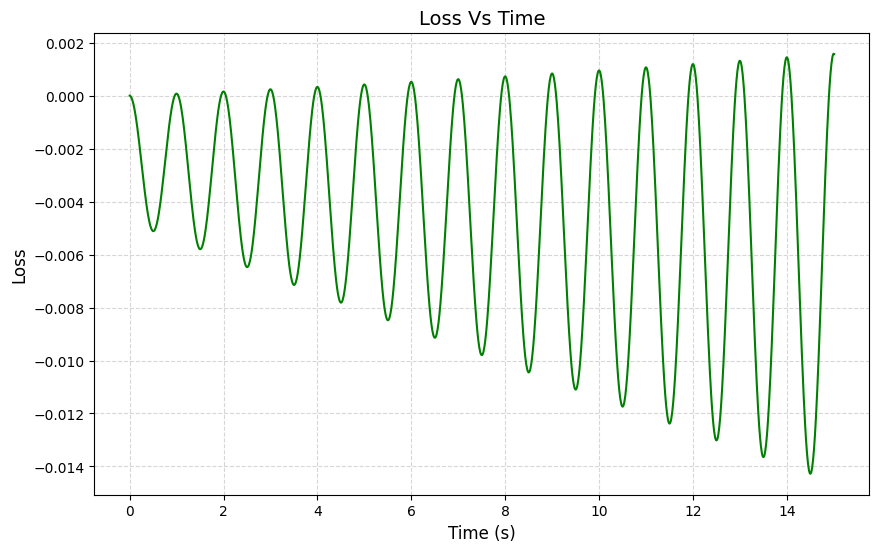

In [16]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_damped_driven.copy()

# Set the desired damping force coefficient:

parameters['C'] = 0.0

# Set the desired driving force amplitude:

parameters['A'] = 1.0

# Set the desired driving force frequency:

parameters['f'] = 0.5

# Set the desired initial state:

state = initial_state_ho.copy()

# Set the desired acceleration function:

acceleration = acceleration_damped_driven

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_damped_driven = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_damped_driven

# Set the Loss Function:

loss = loss_ho

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

[Return to Top](#Notebook-Start)

<a name="Pendulums"></a>

---

#<font size = 6> <b> 3. Pendulums </b> </font>

---

##<font size = 5> <b> 3.1 Pendulums As Simple Harmonic Oscillators </b> </font>

---

##<font size = 5> <b> 3.2 Set the Pendulum Simulation Parameters and Initial State </b> </font>

### <b> Define the Pendulum Simulation Parameters </b>

In [14]:
##=============================================================================================##
## Set the Pendulum Simulation Parameters:                                                     ##
##=============================================================================================##

# Local acceleration due to gravity (in m/s^2):

g = 9.8

# Pendulum length (in m):

length = 5.0

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 10

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_pendulum = pd.Series({
    "g":      g,
    "length": length,
    "dt":     dt,
    "t_end":  t_end
})

# Rename the columns:

parameters_pendulum.name = 'Value'

parameters_pendulum.index.name = "Parameter"

### <b> Define the Pendulum Initial State </b>

In [15]:
##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

# Initial Height:

theta_initial = 1.0 # radians

# Initial Velocity:

v_initial = 0 # radians per second

# Initial Time:

t_initial = 0 # seconds

##=============================================================================================##
## Store the initial state in a Pandas Series:                                                 ##
##=============================================================================================##

initial_state_pendulum = pd.Series({
    "Position" : theta_initial,
    "Velocity" : v_initial,
    "Time"     : t_initial
})

initial_state_pendulum.name = 'Value'

initial_state_pendulum.index.name = "State"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_pendulum, initial_state_pendulum],
                   ["SHO Pendulum Parameters", "Initial State"], n_items = 15)

,Value
Parameter,
g,9.80
length,5.00
dt,0.01
t_end,10.00
,Value
State,
Position,1.0
Velocity,0.0
Time,0.0


---

##<font size = 5> <b> 3.3 Define the Pendulum Acceleration Functions </b> </font>

### <b> Define the Simple Harmonic Oscillator Pendulum Acceleration Function </b>

In [16]:
##=============================================================================================##
## Define the Acceleration Function For the SHO Pendulum Simulation:                           ##
##=============================================================================================##

def acceleration_pendulum_sho(state, parameters):

  ##===========================================================================================##
  ## Unpack the state and parameters:                                                          ##
  ##===========================================================================================##

  # Get the local acceleration of gravity:

  g = parameters["g"]

  # Get the pendulum length:

  L = parameters["length"]

  # Get the object's current position:

  theta = state["Position"]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the acceleration:

  acceleration = - g / L * theta

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration

### <b> Define the Actual Pendulum Acceleration Function </b>

In [17]:
##=============================================================================================##
## Define the Acceleration Function For the Falling Object Simulation:                         ##
##=============================================================================================##

def acceleration_pendulum_actual(state, parameters):

  ##===========================================================================================##
  ## Unpack the state and parameters:                                                          ##
  ##===========================================================================================##

  # Get the local acceleration of gravity:

  g = parameters["g"]

  # Get the pendulum length:

  L = parameters["length"]

  # Get the object's current position:

  theta = state["Position"]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the acceleration:

  acceleration = - g / L * np.sin(theta)

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration

---

##<font size = 5> <b> 3.4 Define the Pendulum Loss Function </b> </font>

In [18]:
##=============================================================================================##
## Create a Function to Calculate Loss:                                                        ##
##=============================================================================================##

def loss_pendulum(parameters, state_history, acceleration):

  ##===========================================================================================##
  ## Unpack Parameter Values:                                                                  ##
  ##===========================================================================================##

  # Get the time step:

  dt = parameters['dt']

  # Get the pendulum length:

  L = parameters['length']

  # Get the local acceleration due to gravity:

  g = parameters['g']

  ##===========================================================================================##
  ## Unpack History Values:                                                                    ##
  ##===========================================================================================##

  # Get the velocity values:

  v_initial = state_history.iloc[0]['Velocity']

  v_history = state_history.iloc[:]['Velocity']

  # Get the position values:

  theta_initial = state_history.iloc[0]['Position']

  theta_history = state_history.iloc[:]['Position']

  ##===========================================================================================##
  ## Calculate the Total Energy Initial:                                                       ##
  ##===========================================================================================##

  potential_energy_initial = g * L * (1 - np.cos(theta_initial))

  kinetic_energy_initial = 0.5 * (L * v_initial) ** 2

  total_energy_initial = potential_energy_initial + kinetic_energy_initial

  ##===========================================================================================##
  ## Calculate the Total Energy History:                                                       ##
  ##===========================================================================================##

  potential_energy_history = g * L * (1 - np.cos(theta_history))

  kinetic_energy_history = 0.5 * (L * v_history) ** 2

  total_energy_history = potential_energy_history + kinetic_energy_history

  ##===========================================================================================##
  ## Calculate the Energy Lost to Non-Conservative Forces (Work / mass = acc * velocity * dt): ##
  ##===========================================================================================##

  # Compute the acceleration due to non-conservative forces:

  acc_nc = acceleration(state_history, parameters) + g / L * np.sin(theta_history)

  # Compute the non-conservative work / mass:

  work = (v_history * acc_nc * dt).cumsum() * L**2

  ##===========================================================================================##
  ## Calculate the Loss History:                                                               ##
  ##===========================================================================================##

  loss_history = (total_energy_history - total_energy_initial - work) / total_energy_initial

  ##===========================================================================================##
  ## Return the Loss History:                                                                  ##
  ##===========================================================================================##

  return loss_history

---

##<font size = 5> <b> 3.5 Run the Pendulum Simulations </b> </font>

### <b> Run the Simple Harmonic Oscillator Pendulum Simulation </b>

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.047198 
 0.000000 
 0.00 
 0.000000 
 
 
 1 
 1.047095 
 -0.020524 
 0.01 
 -0.000037 
 
 
 2 
 1.046787 
 -0.041045 
 0.02 
 -0.000074 
 
 
 3 
 1.046274 
 -0.061557 
 0.03 
 -0.000111 
 
 
 4 
 1.045556 
 -0.082057 
 0.04 
 -0.000148 
 
 
 Final State 
 
 
 
 1001 
 
 
 Time Step 
 
 
 
 
 
 Position 
 0.128654 
 
 
 Velocity 
 -1.454970 
 
 
 Time 
 10.010000 
 
 
 Loss 
 0.000001

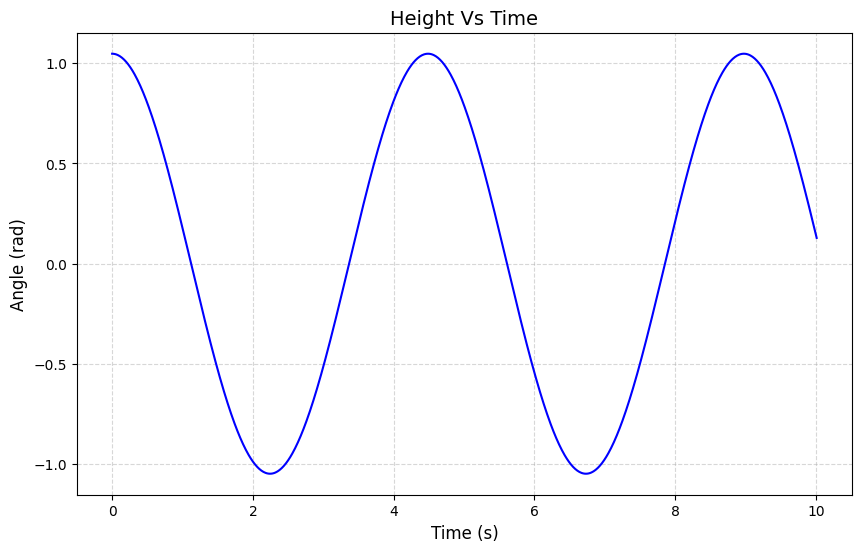

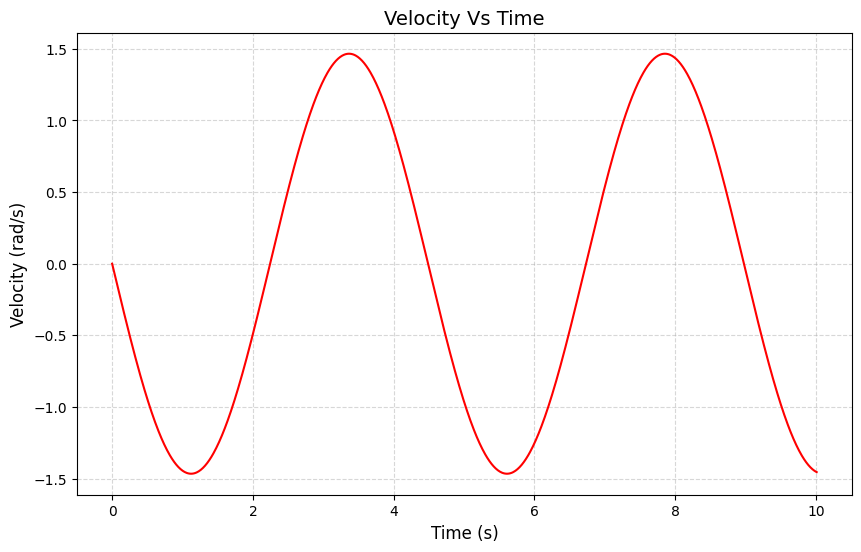

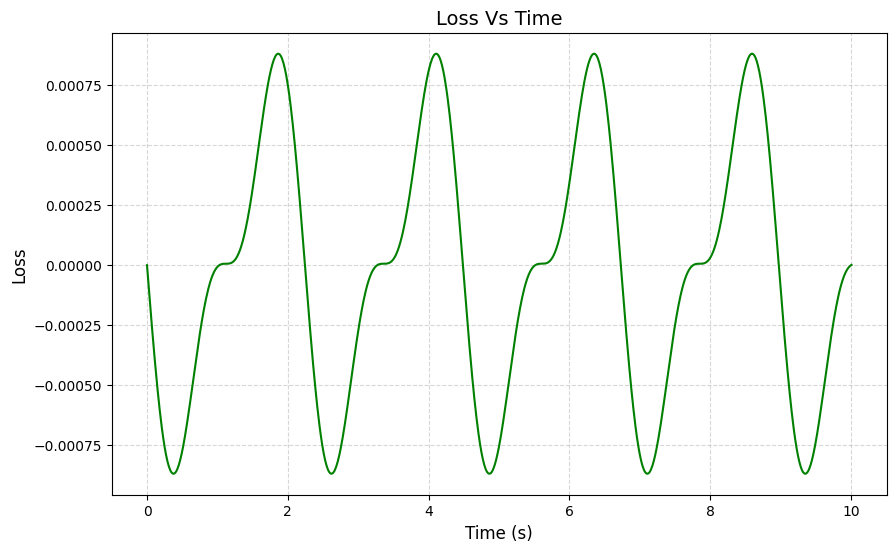

In [26]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_pendulum.copy()

# Set the desired initial state:

state = initial_state_pendulum.copy()

# Set the initial position:

state['Position'] = np.pi / 3.0

# Set the desired acceleration function:

acceleration = acceleration_pendulum_sho

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_pendulum_sho = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_pendulum_sho

# Set the Loss Function:

loss = loss_pendulum

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

### <b> Run the Actual Pendulum Simulation </b>

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.047198 
 0.000000 
 0.00 
 0.000000e+00 
 
 
 1 
 1.047113 
 -0.016974 
 0.01 
 -6.351382e-14 
 
 
 2 
 1.046858 
 -0.033946 
 0.02 
 -2.154830e-13 
 
 
 3 
 1.046434 
 -0.050915 
 0.03 
 -4.556174e-13 
 
 
 4 
 1.045840 
 -0.067879 
 0.04 
 -7.831921e-13 
 
 
 Final State 
 
 
 
 1001 
 
 
 Time Step 
 
 
 
 
 
 Position 
 9.279346e-01 
 
 
 Velocity 
 -6.244954e-01 
 
 
 Time 
 1.001000e+01 
 
 
 Loss 
 -1.212550e-10

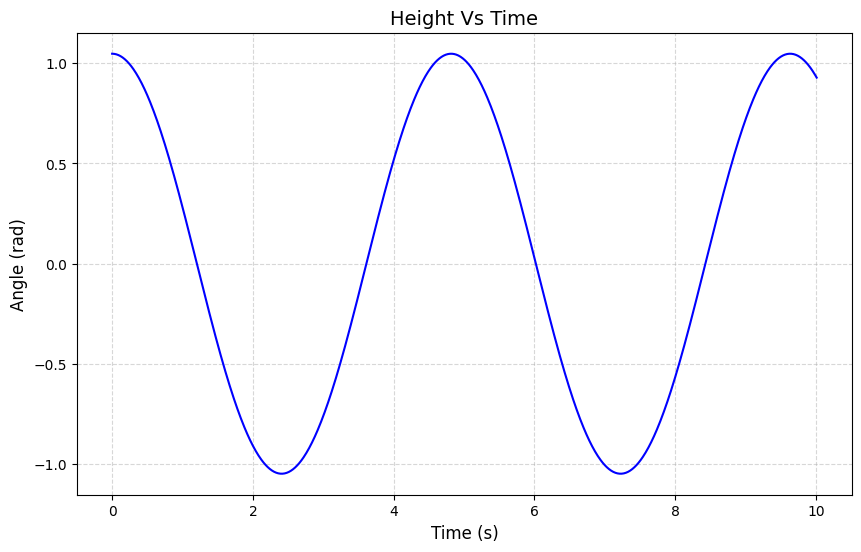

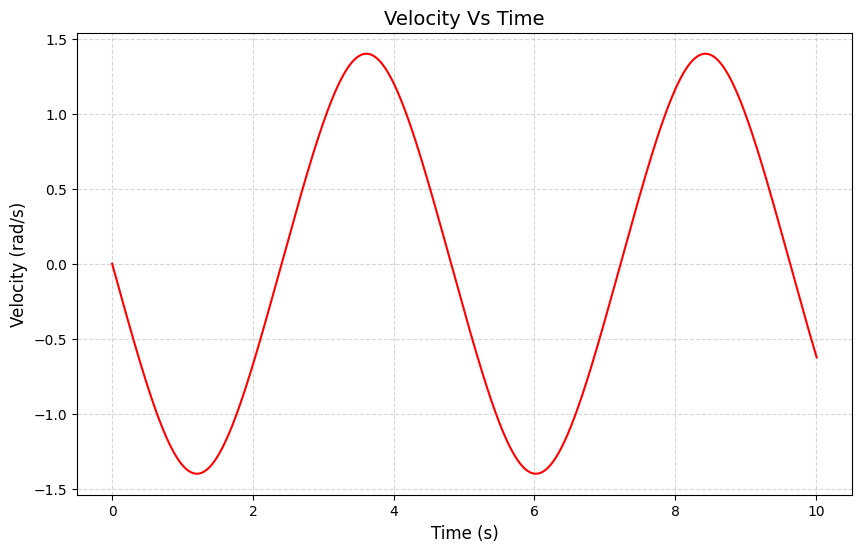

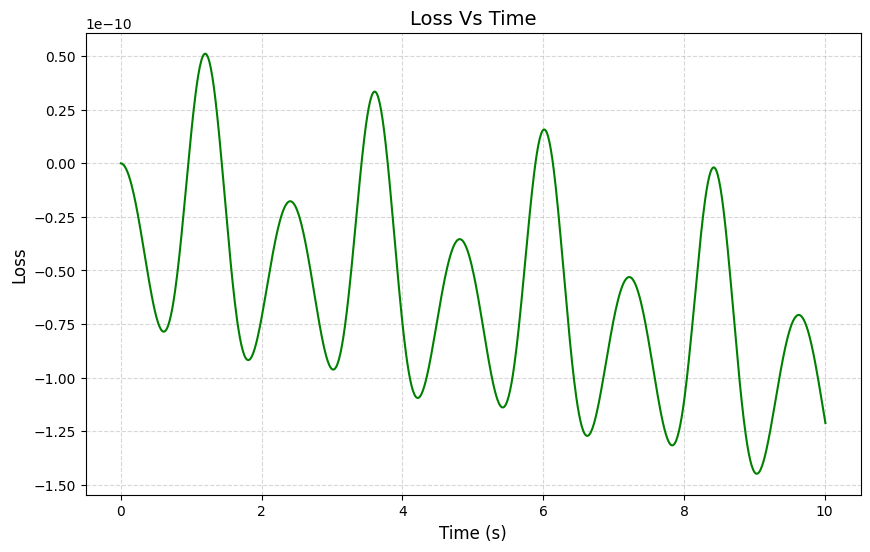

In [27]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_pendulum.copy()

# Set the desired initial state:

state = initial_state_pendulum.copy()

# Set the initial position:

state['Position'] = np.pi / 3.0

# Set the desired acceleration function:

acceleration = acceleration_pendulum_actual

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_pendulum_actual = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_pendulum_actual

# Set the Loss Function:

loss = loss_pendulum

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

---

##<font size = 5> <b> 3.6 Comparing the Pendulum Simulations </b> </font>

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 0.000000 
 0.000000 
 0.00 
 NaN 
 
 
 1 
 0.000017 
 0.002536 
 0.01 
 inf 
 
 
 2 
 0.000068 
 0.005071 
 0.02 
 inf 
 
 
 3 
 0.000153 
 0.007602 
 0.03 
 inf 
 
 
 4 
 0.000271 
 0.010128 
 0.04 
 inf 
 
 
 Final State 
 
 
 
 1001 
 
 
 Time Step 
 
 
 
 
 
 Position 
 0.763256 
 
 
 Velocity 
 0.593197 
 
 
 Time 
 10.010000 
 
 
 Loss 
 inf

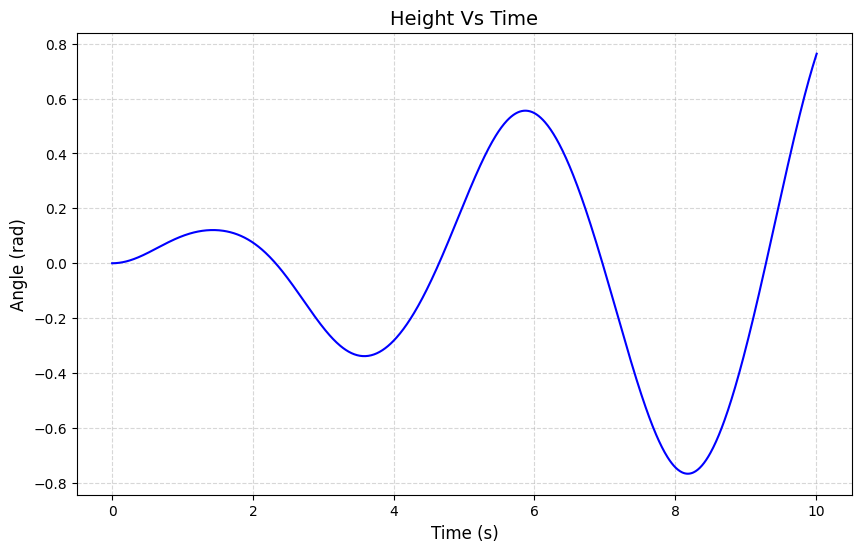

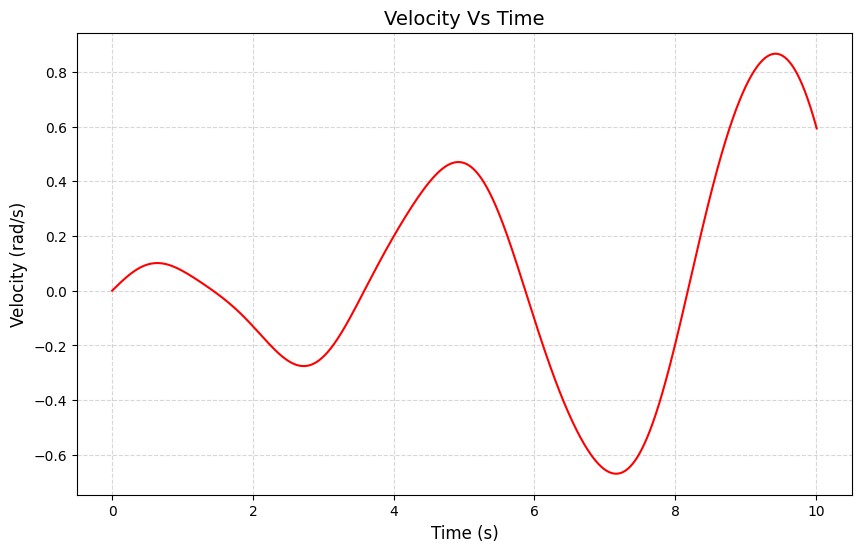

In [40]:
##=============================================================================================##
## Calculate the Difference Between the Simulations:                                           ##
##=============================================================================================##

# Calculate Angular Position Difference:

actual_position = history_pendulum_actual['Position']

sho_position = history_pendulum_sho['Position']

position_difference = (actual_position - sho_position) / np.max(actual_position)

# Calculate the Angular Velocity Difference:

actual_velocity = history_pendulum_actual['Velocity']

sho_velocity = history_pendulum_sho['Velocity']

velocity_difference = (actual_velocity - sho_velocity) / np.max(actual_velocity)

##=============================================================================================##
## Set the Position and Velocity Values of the Difference DataFrame:                           ##
##=============================================================================================##

history_difference = history_pendulum_actual.copy()

history_difference['Position'] = position_difference

history_difference['Velocity'] = velocity_difference

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_difference

# Set the Loss Function:

loss = loss_pendulum

# Set the plotting parameters:

y_list   = ['Position', 'Velocity']
x_list   = ['Time', 'Time']
colors   = ['blue', 'red']
titles   = ['Height Vs Time', 'Velocity Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)']
x_labels = ['Time (s)', 'Time (s)']
aspects  = [0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

[Return to Top](#Notebook-Start)

<a name="Pendulums"></a>

---

#<font size = 6> <b> 4. Double Pendulums </b> </font>

---

In [29]:
##=============================================================================================##
## Set the Coupled Pendulum Simulation Parameters:                                             ##
##=============================================================================================##

# Local acceleration due to gravity (in m/s^2):

g = 9.8

# Pendulum Length (in meters)

length = 5.0

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 10

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_pendulum_double = pd.Series({
    "g":          g,
    "length":     length,
    "dt":         dt,
    "t_end":      t_end
})

# Rename the columns:

parameters_pendulum_double.name = 'Value'

parameters_pendulum_double.index.name = "Parameter"

In [30]:
##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

# Pendulum initial positions:

theta_initial = np.array([0.01, -0.01]) # radians

# Pendulum Initial Velocities:

v_initial = np.array([0.0, 0.0]) # radians per second

# Initial Time:

t_initial = 0 # seconds

##=============================================================================================##
## Store the initial state in a Pandas Series:                                                 ##
##=============================================================================================##

initial_state_pendulum_double = pd.Series({
    "Position" : theta_initial,
    "Velocity" : v_initial,
    "Time"     : t_initial
})

initial_state_pendulum_double.name = 'Value'

initial_state_pendulum_double.index.name = "State"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_pendulum_double, initial_state_pendulum_double],
                   ["Coupled Pendulum Parameters", "Initial State"], n_items = 15)

,Value
Parameter,
g,9.80
length,5.00
dt,0.01
t_end,10.00
,Value
State,
Position,"[0.01, -0.01]"
Velocity,"[0.0, 0.0]"
Time,0


In [55]:
##=============================================================================================##
## Define the Acceleration Function For the Falling Object Simulation:                         ##
##=============================================================================================##

def acceleration_pendulum_coupled(state, parameters):

  ##===========================================================================================##
  ## Unpack the state and parameters:                                                          ##
  ##===========================================================================================##

  # Get the local acceleration of gravity:

  g = parameters["g"]

  # Get the pendulum length:

  L = parameters["length"]

  # Get the separation length:

  S = parameters["separation"]

  # Get the objects' current position:

  theta_1 = state["Position"][0]

  theta_2 = state["Position"][1]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the gravitational acceleration of object 1:

  acceleration_grav_1 = - g / L * np.sin(theta_1)

  # Calculate the gravitational acceleration of object 2:

  acceleration_grav_2 = - g / L * np.sin(theta_2)

  # Calculate the spring acceleration of object 1:

  spring_force_x = spring_force_magnitude * (x_2 - x_1) / separation

  spring_force_y = spring_force_magnitude * (y_2 - y_1) / separation

  spring_force_1 = spring_force_x * np.cos(theta_1) + spring_force_y * np.sin(theta_1)

  acceleration_1 = acceleration_grav_1 + spring_force_1 / L

  # Calculate the spring acceleration of object 1:

  spring_force_x = spring_force_magnitude * (x_1 - x_2) / separation

  spring_force_y = spring_force_magnitude * (y_1 - y_2) / separation

  spring_force_2 = spring_force_x * np.cos(theta_2) + spring_force_y * np.sin(theta_2)

  acceleration_2 = acceleration_grav_2 + spring_force_2 / L

  # Combine the accelerations into a list:

  acceleration = np.array([acceleration_1, acceleration_2])

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration

In [60]:
def loss_temp(state, parameters, acceleration):
  return 0

##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_pendulum_coupled.copy()

# Set the desired initial state:

state = initial_state_pendulum_coupled.copy()

# Set the desired acceleration function:

acceleration = acceleration_pendulum_coupled

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_pendulum_coupled = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_pendulum_coupled

# Set the Loss Function:

loss = loss_temp

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 [0.02354822273214154, -0.02354822273214154] 
 [-0.004008369947421332, 0.004008369947421332] 
 0 
 0 
 
 
 1 
 [0.02354822273214154, -0.02354822273214154] 
 [-0.004008369947421332, 0.004008369947421332] 
 0.01 
 0 
 
 
 2 
 [0.02354822273214154, -0.02354822273214154] 
 [-0.004008369947421332, 0.004008369947421332] 
 0.02 
 0 
 
 
 3 
 [0.02354822273214154, -0.02354822273214154] 
 [-0.004008369947421332, 0.004008369947421332] 
 0.03 
 0 
 
 
 4 
 [0.02354822273214154, -0.02354822273214154] 
 [-0.004008369947421332, 0.004008369947421332] 
 0.04 
 0 
 
 
 Final State 
 
 
 
 1001 
 
 
 Time Step 
 
 
 
 
 
 Position 
 [0.02354822273214154, -0.02354822273214154] 
 
 
 Velocity 
 [-0.004008369947421332, 0.004008369947421332] 
 
 
 Time 
 10.01 
 
 
 Loss 
 0

TypeError: no numeric data to plot

In [35]:
a = acceleration_pendulum_coupled(initial_state_pendulum_coupled, parameters_pendulum_coupled)
print(a)

[0.01, -0.01]
[np.float64(0.0003989933583663889), np.float64(-0.0003989933583663889)]


In [21]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Local acceleration due to gravity (in m/s^2):

g = 9.8

# Pendulum length (in m):

length = 5.0

# Damping coefficient:

C = 0.2

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 10

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_pendulum_damped = pd.Series({
    "g":      g,
    "C":      C,
    "length": length,
    "dt":     dt,
    "t_end":  t_end
})

# Rename the columns:

parameters_pendulum_damped.name = 'Value'

parameters_pendulum_damped.index.name = "Parameter"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_pendulum_damped, initial_state],
                   ["Damped Pendulum Parameters", "Initial State"], n_items = 15)

NameError: name 'initial_state' is not defined

In [16]:
##=============================================================================================##
## Define the Acceleration Function For the Falling Object Simulation:                         ##
##=============================================================================================##

def acceleration_pendulum_damped(state, parameters):

  ##===========================================================================================##
  ## Unpack the state and parameters:                                                          ##
  ##===========================================================================================##

  # Get the local acceleration of gravity:

  g = parameters["g"]

  # Get the pendulum length:

  L = parameters["length"]

  # Get the damping coefficient:

  C = parameters["C"]

  # Get the object's current position:

  theta = state["Position"]

  # Get the object's current velocity:

  v = state["Velocity"]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the acceleration due to gravity:

  acceleration_grav = - g / L * np.sin(theta)

  # Calculate the acceleration due to drag:

  acceleration_drag = - C * v

  # Calculate the total acceleration:

  acceleration = acceleration_grav + acceleration_drag

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 0.031416 
 0.000000 
 0.00 
 0.000000e+00 
 
 
 1 
 0.031413 
 -0.000615 
 0.01 
 5.213252e-07 
 
 
 2 
 0.031404 
 -0.001229 
 0.02 
 1.820528e-06 
 
 
 3 
 0.031388 
 -0.001841 
 0.03 
 3.891928e-06 
 
 
 4 
 0.031367 
 -0.002451 
 0.04 
 6.729268e-06 
 
 
 Final State 
 
 
 
 1001 
 
 
 Time Step 
 
 
 
 
 
 Position 
 0.002648 
 
 
 Velocity 
 -0.016000 
 
 
 Time 
 10.010000 
 
 
 Loss 
 0.000265

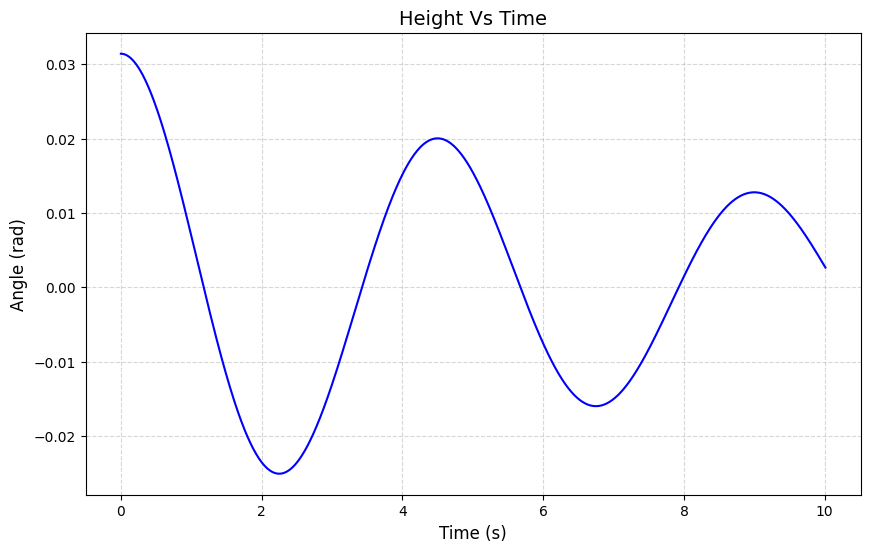

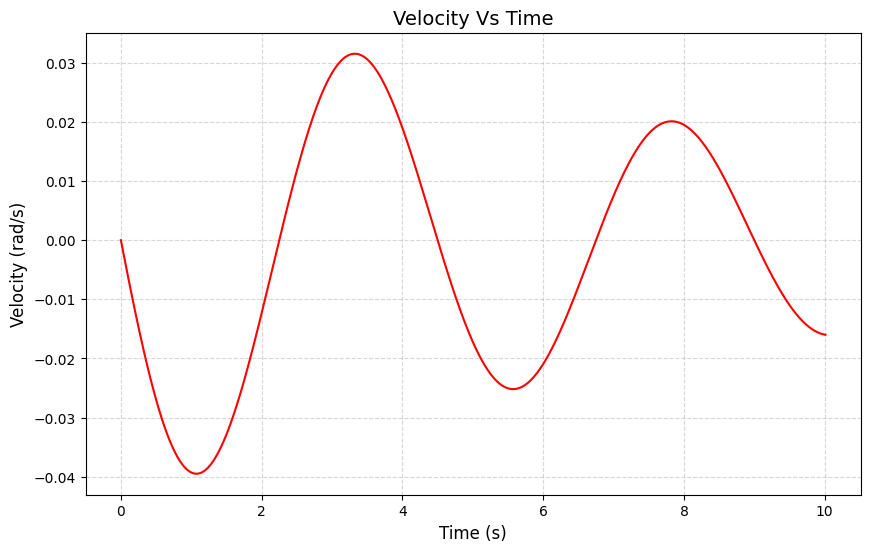

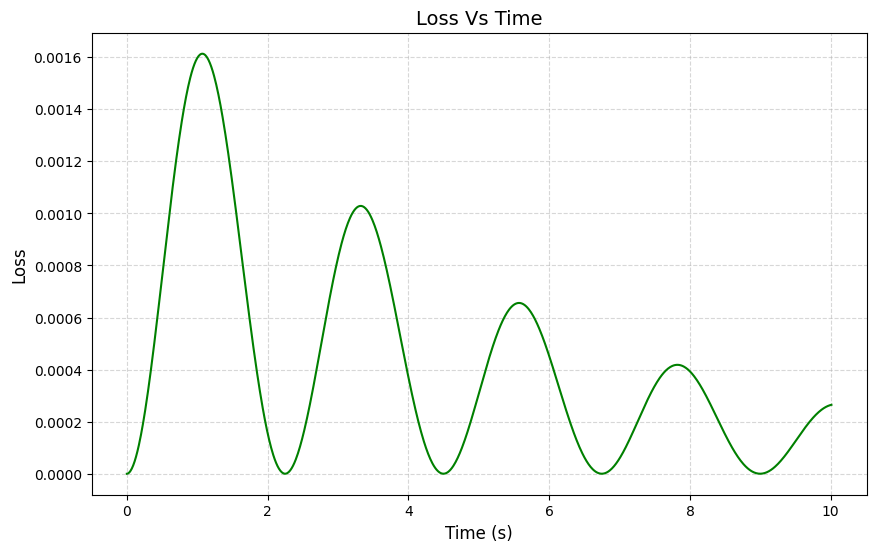

In [17]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_pendulum_damped.copy()

# Set the desired initial state:

state = initial_state.copy()

# Set the initial position:

state['Position'] = np.pi / 100.0

# Set the desired acceleration function:

acceleration = acceleration_pendulum_damped

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_damped = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_damped

# Set the Loss Function:

loss = loss_pendulum

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

In [80]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Local acceleration due to gravity (in m/s^2):

g = 9.8

# Pendulum length (in m):

length = 5.0

# Damping coefficient:

C = 0.2

# Driving force amplitude:

A = 0.1

# Driving force frequency:

f = 1.0

# Driving force phase:

phi = 0.0

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 15

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_pendulum_damped_driven = pd.Series({
    "g":      g,
    "C":      C,
    "A":      A,
    "f":      f,
    "phi":    phi,
    "length": length,
    "dt":     dt,
    "t_end":  t_end
})

# Rename the columns:

parameters_pendulum_damped.name = 'Value'

parameters_pendulum_damped.index.name = "Parameter"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_pendulum_damped_driven, initial_state],
                   ["Damped Pendulum Parameters", "Initial State"], n_items = 15)

,0
g,9.80
C,0.20
A,0.10
f,1.00
phi,0.00
length,5.00
dt,0.01
t_end,15.00
,Value
State,


In [85]:
##=============================================================================================##
## Define the Acceleration Function For the Falling Object Simulation:                         ##
##=============================================================================================##

def acceleration_pendulum_damped_driven(state, parameters):

  ##===========================================================================================##
  ## Unpack the state and parameters:                                                          ##
  ##===========================================================================================##

  # Get the local acceleration of gravity:

  g = parameters["g"]

  # Get the pendulum length:

  L = parameters["length"]

  # Get the damping coefficient:

  C = parameters["C"]

  # Get the driving force amplitude:

  A = parameters["A"]

  # Get the driving force frequency:

  f = parameters["f"]

  # Get the driving fore phase:

  phi = parameters["phi"]

  # Get the object's current position:

  theta = state["Position"]

  # Get the object's current velocity:

  v = state["Velocity"]

  ##===========================================================================================##
  ## Calculate the Net Force on the Object:                                                    ##
  ##===========================================================================================##

  # Calculate the acceleration due to gravity:

  acceleration_grav = - g / L * theta # np.sin(theta)

  # Calculate the acceleration due to drag:

  acceleration_drag = - C * v

  # Calculate the acceleration due to the driving force:

  acceleration_drive = A * np.cos((2 * np.pi) * f * state["Time"] + phi)

  # Calculate the total acceleration:

  acceleration = acceleration_grav + acceleration_drag + acceleration_drive

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return acceleration

State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 0.010000 
 0.000000 
 0.00 
 0.000000 
 
 
 1 
 0.009999 
 -0.000147 
 0.01 
 0.000059 
 
 
 2 
 0.009997 
 -0.000293 
 0.02 
 0.000119 
 
 
 3 
 0.009993 
 -0.000440 
 0.03 
 0.000178 
 
 
 4 
 0.009988 
 -0.000587 
 0.04 
 0.000237 
 
 
 Final State 
 
 
 
 1501 
 
 
 Time Step 
 
 
 
 
 
 Position 
 -0.047635 
 
 
 Velocity 
 0.013113 
 
 
 Time 
 15.010000 
 
 
 Loss 
 -0.051946

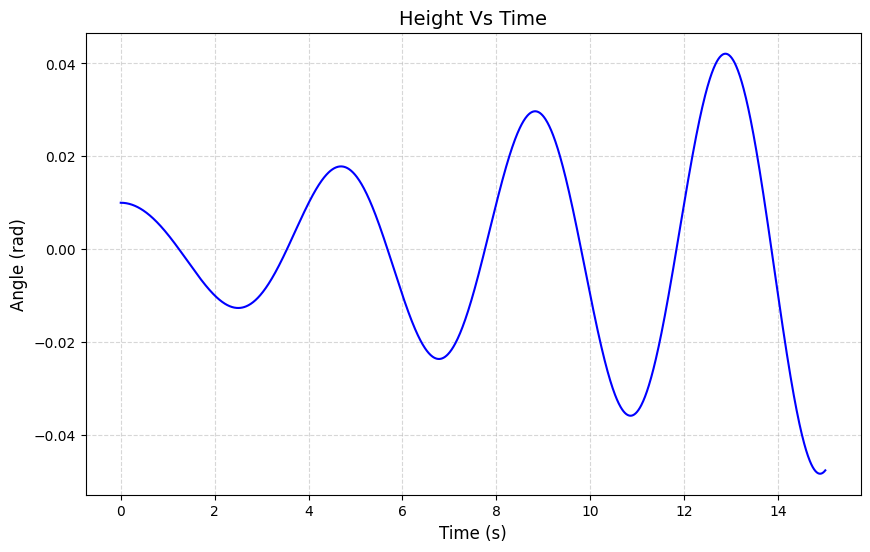

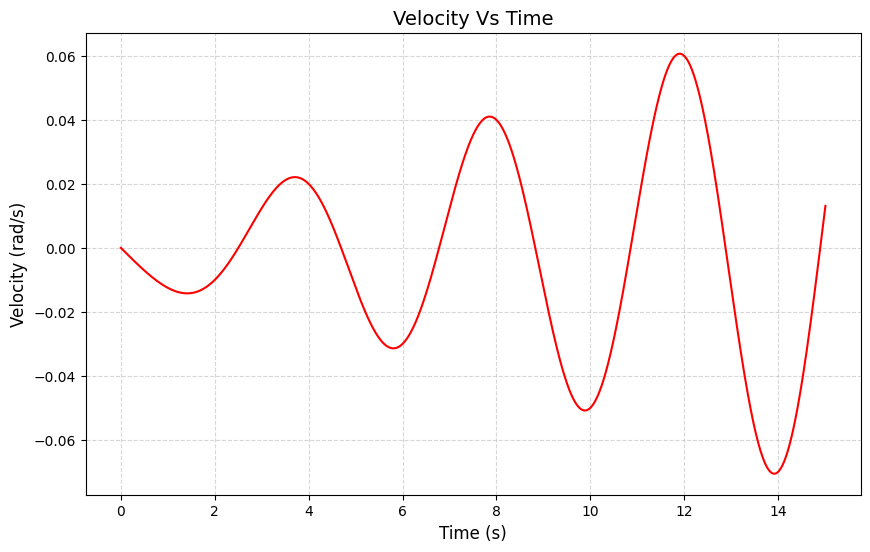

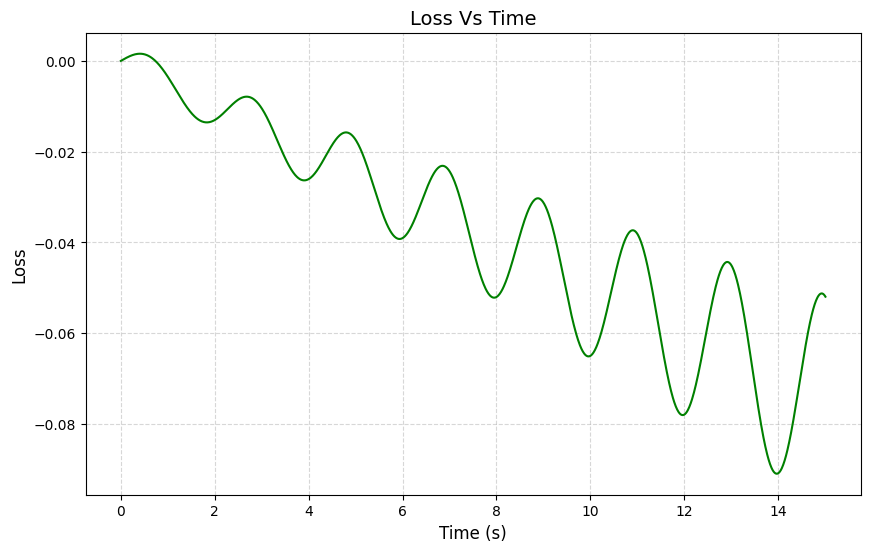

In [87]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the desired parameter set:

parameters = parameters_pendulum_damped_driven.copy()

# Set the desired initial state:

state = initial_state.copy()

# Set the initial position:

state['Position'] = 0.01

parameters['length'] = parameters['g'] / (0.5 * np.pi)**2

parameters['C'] = 0

parameters['A'] = 0.01

parameters['f'] = 0.25

# Set the desired acceleration function:

acceleration = acceleration_pendulum_damped_driven

# Set the desired change function:

change_function = cf_runge_kutta_1d

# Run the simulation:

history_damped_driven = run_simulation(parameters, state, change_function, acceleration)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

# Set the history to be plotted:

history = history_damped_driven

# Set the Loss Function:

loss = loss_pendulum

# Set the plotting parameters:

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Angle (rad)', 'Velocity (rad/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

# Run the analyze simulation function:

analyze_simulation(history, parameters, loss, acceleration, x_list, y_list, colors, titles,
                   x_labels, y_labels, aspects, plot= True, display = True)

[Return to Top](#Notebook-Start)

---